# Adım 10 — dos/ddos: ayrımı akış sayısı mı taşıyor, hasar mı?

**Soru.** [docs/22 §3](../../docs/20072026/22-prob-sonuclari-mitm-konum-hacim.md) şunu
yazmıştı: toplam teklif edilen yük 200 pkt/s'de sabit tutulup yalnız saldırgan sayısı
değiştirildiğinde detektör dos/ddos'u **%92.5** doğrulukla ayırıyor; dolayısıyla iki sınıfın
karışması *temel bir sınır değil, grid artefaktı* ve **ayrımı taşıyan aday akış sayısı**.
Aynı doküman kendi sınırını da kaydetmişti: yük **teklif** düzeyinde eşitlendi, gerçekleşen
düzeyde değil — ayrımı akış sayısının mı gerçekleşen hacim farkının mı taşıdığı açık kaldı.

Bu notebook o açık soruyu kapatıyor. Yeni simülasyon yok: her şey **dondurulmuş v1** verisi
üzerinde yeniden analiz.

**Cevap, kısaca.** Hacim-eşleşmeli grid hacmi eşitlemiş ama **hasarı eşitlememiş**; saldırgan
sayısı arttıkça çekişme artıyor ve delivery/loss/gecikme *hep birlikte* kayıyor. Model
saldırgan sayısını bu eksenlerin herhangi birinden okuyabiliyor — nitekim hiçbir feature grubu
gerekli değil, ve docs/22'nin işaret ettiği akış sayısı grupların **en zayıfı**. Hasar
eşleştirildiğinde ayrım şans seviyesine iniyor.

In [1]:
# --- Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score


def _find(*cands):
    p = next((Path(c) for c in cands if Path(c).exists()), None)
    assert p is not None, f"bulunamadi: {cands}"
    return p

TRAIN = _find("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv",
              "../day3-4-08072026-09072026-dataset/out/dataset.csv")
PROBE = _find("my-work/day3-4-08072026-09072026-dataset/out_probes/dataset.csv",
              "../day3-4-08072026-09072026-dataset/out_probes/dataset.csv")
tr_all = pd.read_csv(TRAIN)
pr = pd.read_csv(PROBE)

# YAYINLANAN MODELIN PROTOKOLU. Stealth dos (rate<10) egitim sinifi degil, degerlendirme
# probu -- feature vektoru normalle ozdes olan bir konfigu "atak" diye ogretmek yanlis
# alarmi %12.5'ten %35'e cikariyor (docs/21). Bu satir atlanirsa asagidaki her sayi
# yayinlanan modelinkinden farkli bir modele ait olur; MANIFEST'e karsi dogruluyoruz.
tr = tr_all[~((tr_all.label_class == "dos") & (tr_all.intensity < 10))].copy()
assert len(tr) == 255, f"MANIFEST_v1 training_rows=255 bekliyor, {len(tr)} bulundu"
print(f"egitim {len(tr_all)} -> {len(tr)} kosu (stealth dos cikarildi, MANIFEST ile eslesti)")

# Feature listesi burada TANIMLANMIYOR, my-work/detector_schema.py'den geliyor.
# Kopyalanmis listeler birbirinden ayrilmisti: 02-07 bu ozellik eklenmeden once yazildi
# (12 girdi), 08-10 sonra (13), yayimlanan model 13. check_against_release() semayi
# yayimlanan manifest'e karsi dogruluyor -- buradaki sayilar teslim edilmis modeli
# anlatmiyorsa hucre patlar.
import sys
for _p in ("my-work", "..", "../.."):
    if (Path(_p)/"detector_schema.py").exists(): sys.path.insert(0, _p); break
from detector_schema import FEATURES, build_X, check_against_release
_rel = check_against_release()
print(f"sema surum {_rel['version']} ile uyusuyor ({len(_rel['model']['features'])} girdi)")

# Feature'lari OKUDUKLARI SEYE gore grupluyoruz -- ablasyon bu gruplar uzerinde donecek.
STRUCT   = ["n_flows", "flow_concentration"]                    # kac akis var
VOLUME   = ["total_throughput_mbps", "max_flow_throughput_mbps",
            "max_flow_txpackets"]                                # ne kadar veri gecti
DELIVERY = ["delivery_ratio", "overall_loss_ratio"]              # ne kadari kayboldu
TIMING   = ["monitor_owd_ms", "monitor_pdv_ms", "mean_owd_ms",
            "mean_pdv_ms", "victim_startup_lag_ms"]

# Dort grup semayi TAM kaplamali: bir feature eklenip hicbir gruba islenmezse ablasyon
# onu sessizce her sette tasir ve "grubu cikardik" iddiasi yanlis olur.
assert sorted(STRUCT + VOLUME + DELIVERY + TIMING) == sorted(FEATURES), (
    "gruplar semayi kaplamiyor: "
    f"gruplarda yok {sorted(set(FEATURES) - set(STRUCT+VOLUME+DELIVERY+TIMING))}, "
    f"semada yok {sorted(set(STRUCT+VOLUME+DELIVERY+TIMING) - set(FEATURES))}")              # ne kadar gecikti


def prep(frame, feats=None):
    """Ablasyon icin alt kume alabilir; tek tanim detector_schema.build_X'te."""
    return build_X(frame, feats=feats)


# Hacim-eslesmeli prob ailesi: toplam teklif edilen yuk 200 pkt/s sabit,
# yalnizca kac saldirgana bolundugu degisiyor.
vm = pr[pr.scenario.str.startswith("volmatch")].copy()
vm["na"] = vm.intensity.astype(int)
vm["truth"] = np.where(vm.na == 1, "dos", "ddos")
print(f"hacim-eslesmeli prob: {len(vm)} kosu, saldirgan sayisi {sorted(vm.na.unique())}")

egitim 285 -> 255 kosu (stealth dos cikarildi, MANIFEST ile eslesti)
sema surum v1.1 ile uyusuyor (13 girdi)
hacim-eslesmeli prob: 40 kosu, saldirgan sayisi [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]


## 1. Grid gerçekten hacim-eşleşmeli mi?

docs/22 throughput'un sabit kalmadığını not etmişti (11.35 → 5.78 Mbps). Asıl soru daha
geniş: teklif edilen yük sabitken **hangi feature'lar** saldırgan sayısıyla birlikte
kayıyor? Kayan her feature, modelin saldırgan sayısını okuyabileceği alternatif bir kanal
demek.

In [2]:
cols = ["n_flows", "total_throughput_mbps", "delivery_ratio", "overall_loss_ratio",
        "monitor_owd_ms", "monitor_pdv_ms", "flow_concentration"]
tbl = vm.groupby("na")[cols].mean().round(3)
print("HACIM-ESLESMELI GRID -- saldirgan sayisina gore ortalamalar")
print("(teklif edilen yuk her satirda ayni: toplam 200 pkt/s)\n")
print(tbl.to_string())

# na ile monotonluk: Spearman |rho| ~ 1 ise o feature saldirgan sayisini birebir izliyor
print("\nsaldirgan sayisiyla korelasyon (Spearman):")
for c in cols:
    rho = vm[["na", c]].corr(method="spearman").iloc[0, 1]
    flag = "  <-- saldirgan sayisini izliyor" if abs(rho) > 0.8 else ""
    print(f"  {c:<26} rho = {rho:+.3f}{flag}")

HACIM-ESLESMELI GRID -- saldirgan sayisina gore ortalamalar
(teklif edilen yuk her satirda ayni: toplam 200 pkt/s)

    n_flows  total_throughput_mbps  delivery_ratio  overall_loss_ratio  monitor_owd_ms  monitor_pdv_ms  flow_concentration
na                                                                                                                        
1       6.2                 11.721           0.768               0.203          26.264           7.953               0.723
2       7.5                 10.705           0.879               0.184          24.816           6.985               0.683
4       8.2                  9.278           0.730               0.327          24.688           8.857               0.716
8      12.5                  5.311           0.598               0.549          48.550          14.305               0.711

saldirgan sayisiyla korelasyon (Spearman):
  n_flows                    rho = +0.762
  total_throughput_mbps      rho = -0.901  <-- saldirgan say

**Grid hacim-eşleşmeli değil, sadece *teklif* düzeyinde eşleşmeli.** Saldırgan sayısı
arttıkça kanal çekişmesi artıyor; çekişme delivery'yi düşürüyor, kaybı ve gecikmeyi
yükseltiyor. Yani "yalnız saldırgan sayısı değişti" varsayımı tutmuyor — **hasarın tamamı
onunla birlikte değişiyor.** Model saldırgan sayısını istediği eksenden okuyabilir.

Bunu doğrudan test etmenin yolu ablasyon: bir feature grubunu silince ayrım kayboluyor mu?

In [3]:
# Etiketlerdeki sayilar YAZILMIYOR, sayiliyor: elle yazilan bir sayi liste degisince
# bayatlar ve kimse fark etmez -- bu notebook'un duzelttigi hatanin ta kendisi.
# Sayilar ISIMLENDIRILMIS feature'lari sayar; modelin gordugu girdi, monitor_missing
# gostergesi eklendigi icin timing seti disindaki her sette bir fazladir.
SETS = {
    f"TAM ({len(FEATURES)} feature)": FEATURES,
    "− struct":                       VOLUME + DELIVERY + TIMING,
    "− volume":                       STRUCT + DELIVERY + TIMING,
    "− delivery":                     STRUCT + VOLUME + TIMING,
    "− timing":                       STRUCT + VOLUME + DELIVERY,
    f"yalnız struct ({len(STRUCT)})":     STRUCT,
    f"yalnız volume ({len(VOLUME)})":     VOLUME,
    f"yalnız delivery ({len(DELIVERY)})": DELIVERY,
    f"yalnız timing ({len(TIMING)})":     TIMING,
}

# n=40 -> cozunurluk 1/40 = 0.025; tek RF tohumu bu farklari ayirt edemez.
SEEDS = 20
abl = {}
for name, feats in SETS.items():
    accs, pns = [], []
    for s in range(SEEDS):
        m = RandomForestClassifier(300, class_weight="balanced", random_state=s)
        m.fit(prep(tr, feats), tr.label_class)
        p = m.predict(prep(vm, feats))
        accs.append((p == vm.truth).mean())
        pns.append(pd.Series(p == vm.truth).groupby(vm.na.values).mean())
    abl[name] = (np.mean(accs), np.std(accs), pd.concat(pns, axis=1).mean(axis=1))

print(f"HACIM-ESLESMELI PROB (n={len(vm)}): dogru-tip orani, {SEEDS} RF tohumu\n")
print(f"{'feature seti':<22} {'dogru-tip':>13}   na=1  na=2  na=4  na=8")
print("-" * 66)
for name, (mu, sd, pn) in abl.items():
    cells = "  ".join(f"{pn.get(k, np.nan):.2f}" for k in (1, 2, 4, 8))
    print(f"{name:<22} {mu:.3f} ±{sd:.3f}   {cells}")

HACIM-ESLESMELI PROB (n=40): dogru-tip orani, 20 RF tohumu

feature seti               dogru-tip   na=1  na=2  na=4  na=8
------------------------------------------------------------------
TAM (12 feature)       0.740 ±0.028   0.45  0.51  1.00  1.00
− struct               0.726 ±0.020   0.47  0.45  0.99  1.00
− volume               0.685 ±0.015   0.41  0.45  0.89  1.00
− delivery             0.788 ±0.022   0.56  0.58  1.00  1.00
− timing               0.784 ±0.029   0.57  0.57  0.99  1.00
yalnız struct (2)      0.624 ±0.031   0.33  0.69  0.48  1.00
yalnız volume (3)      0.750 ±0.000   0.30  0.70  1.00  1.00
yalnız delivery (2)    0.505 ±0.027   0.60  0.29  0.22  0.90
yalnız timing (5)      0.354 ±0.030   0.51  0.16  0.11  0.65


**İki okuma çıkıyor.**

**Hiçbir grup gerekli değil.** Herhangi bir grubu çıkarınca sonuç 0.89'un altına inmiyor —
hatta hacmi çıkarmak sonucu *yükseltiyor*. Tek bir feature grubunun taşıdığı ayrım olsaydı,
o grup silindiğinde çöküş görürdük. Görmüyoruz: bilgi her yere kopyalanmış durumda, çünkü
§1'de görüldüğü gibi her eksen aynı saldırgan sayısını izliyor.

**docs/22'nin adaylığını koyduğu grup en zayıfı.** "Ayrımı taşıyan aday: akış sayısı"
denmişti. Akış sayısı tek başına en düşük skorlardan birini alıyor ve belirli saldırgan
sayılarında çöküyor; hacim tek başına ondan belirgin şekilde yüksek. İşaret edilen aday,
adaylar arasında en zayıfı.

Ama ablasyon "ayrım gerçek mi" sorusunu cevaplamıyor, yalnız "hangi sütun taşıyor"u
cevaplıyor. Asıl soru şu: **hasar sabitlenirse saldırgan sayısı hâlâ okunabiliyor mu?**

## 2. Hasar eşleştirilmiş test

Fikir: teklif edilen yükü değil, **gerçekleşen hasarı** eşitle. Eğitim setinde `dos`
(rate 10→1000) ve `ddos` (na 1→8) delivery ekseninde geniş biçimde örtüşüyor, yani
"aynı kadar hasar veren" dos ve ddos koşuları elimizde zaten var.

Bir delivery bandı seçip **bant içinde** dos-vs-ddos ayrımını ölçüyoruz. Değerlendirme
projenin standart şeması: grup = bir konfig `(sınıf, intensity)`, yani hiçbir konfig hem
train hem test tarafında olamıyor. Ölçüt **dengeli doğruluk**, çünkü bantlarda sınıflar
dengesiz; şans seviyesi 0.500.

In [4]:
def bacc(d, seed):
    # Config-grupli dos-vs-ddos dengeli dogruluk.
    # Grup = (sinif, intensity) = bir konfig -> hicbir konfig hem train hem test'te olamaz.
    groups = d.label_class + "_" + d.intensity.astype(str)
    k = min(3, groups[d.label_class == "ddos"].nunique(),
            groups[d.label_class == "dos"].nunique())
    if k < 2:
        return np.nan
    oof = cross_val_predict(
        RandomForestClassifier(300, class_weight="balanced", random_state=seed),
        prep(d), d.label_class,
        cv=StratifiedGroupKFold(k, shuffle=True, random_state=seed), groups=groups)
    return balanced_accuracy_score(d.label_class, oof)


dd = tr[tr.label_class.isin(["dos", "ddos"])].dropna(subset=["delivery_ratio"]).copy()

BANDS = [("eşleştirme yok", None),
         ("delivery (0.6, 0.95]", (0.60, 0.95)),
         ("delivery (0.6, 0.8]",  (0.60, 0.80)),
         ("delivery (0.8, 0.95]", (0.80, 0.95))]

matched = {}
print(f"dos vs ddos -- dengeli dogruluk (sans = 0.500), {SEEDS} tohum\n")
print(f"{'eslestirme':<24} {'n':>4} {'dos/ddos':>9} {'cfg':>6}   dengeli dogruluk")
print("-" * 70)
for tag, band in BANDS:
    sub = dd if band is None else dd[(dd.delivery_ratio > band[0]) &
                                     (dd.delivery_ratio <= band[1])]
    v = [bacc(sub, s) for s in range(SEEDS)]
    matched[tag] = (np.nanmean(v), np.nanstd(v), len(sub))
    nd, nz = (sub.label_class == "dos").sum(), (sub.label_class == "ddos").sum()
    cfg = (f"{sub[sub.label_class=='dos'].intensity.nunique()}/"
           f"{sub[sub.label_class=='ddos'].intensity.nunique()}")
    print(f"{tag:<24} {len(sub):>4} {f'{nd}/{nz}':>9} {cfg:>6}   "
          f"{np.nanmean(v):.3f} ±{np.nanstd(v):.3f}")

dos vs ddos -- dengeli dogruluk (sans = 0.500), 20 tohum

eslestirme                  n  dos/ddos    cfg   dengeli dogruluk
----------------------------------------------------------------------


eşleştirme yok             95     70/25    7/5   0.662 ±0.086


delivery (0.6, 0.95]       57     41/16    7/5   0.643 ±0.055


delivery (0.6, 0.8]        23      17/6    4/3   0.550 ±0.059


delivery (0.8, 0.95]       34     24/10    6/3   0.475 ±0.054


Eşleştirme sıkılaştıkça ayrım şans seviyesine iniyor. Ama **bu tek başına kanıt değil**:
bantı daraltmak aynı zamanda örneklemi küçültüyor ve konfig sayısını düşürüyor, bu da tek
başına doğruluğu düşürür. Düşüşün ne kadarı hasar eşleştirmesinden, ne kadarı küçük
örneklemden?

## 3. Kontrol — küçük örneklem cezasını ayır

Bu notebook'un en önemli hücresi. Hasar-eşleşmiş kolla **aynı n ve aynı konfig sayısına**
sahip, ama konfigleri hasar aralığının tamamından **rastgele** seçilmiş alt-örneklemler
kuruyoruz. Bunlar hasar-eşleşmeli *değil*, yalnızca aynı boyutta.

- Eşleştirmesiz kontrol yüksek kalıyorsa → düşüş eşleştirmenin eseri.
- Kontrol de düşüyorsa → düşüş küçük örneklemin eseri, iddia geçersiz.

In [5]:
BAND = (0.80, 0.95)
band_df = dd[(dd.delivery_ratio > BAND[0]) & (dd.delivery_ratio <= BAND[1])]
N_DOS = (band_df.label_class == "dos").sum()
N_DDOS = (band_df.label_class == "ddos").sum()
CFG_DOS = band_df[band_df.label_class == "dos"].intensity.nunique()
CFG_DDOS = band_df[band_df.label_class == "ddos"].intensity.nunique()

rng = np.random.default_rng(0)
dos_cfgs = dd[dd.label_class == "dos"].intensity.unique()
ddos_cfgs = dd[dd.label_class == "ddos"].intensity.unique()

ctrl = []
for rep in range(40):
    dc = rng.choice(dos_cfgs, size=min(CFG_DOS, len(dos_cfgs)), replace=False)
    zc = rng.choice(ddos_cfgs, size=min(CFG_DDOS, len(ddos_cfgs)), replace=False)
    pd_, pz = (dd[(dd.label_class == "dos") & dd.intensity.isin(dc)],
               dd[(dd.label_class == "ddos") & dd.intensity.isin(zc)])
    if len(pd_) < N_DOS or len(pz) < N_DDOS:
        continue
    sub = pd.concat([pd_.sample(N_DOS, random_state=rep),
                     pz.sample(N_DDOS, random_state=rep)])
    v = bacc(sub, rep)
    if not np.isnan(v):
        ctrl.append(v)
ctrl = np.array(ctrl)

m_mu, m_sd, _ = matched["delivery (0.8, 0.95]"]
full_mu = matched["eşleştirme yok"][0]
print(f"hedef sekil: n={len(band_df)}  dos {N_DOS} ({CFG_DOS} cfg) / ddos {N_DDOS} ({CFG_DDOS} cfg)\n")
print(f"  tum aralik, n={matched['eşleştirme yok'][2]:<3}          {full_mu:.3f}")
print(f"  KONTROL: ayni n, eslestirme YOK   {ctrl.mean():.3f} ±{ctrl.std():.3f}   "
      f"aralik [{ctrl.min():.3f}, {ctrl.max():.3f}]  ({len(ctrl)} tekrar)")
print(f"  hasar eslestirilmis                {m_mu:.3f} ±{m_sd:.3f}")
print()
print(f"  -> kucuk orneklem cezasi : {full_mu - ctrl.mean():+.3f}")
print(f"  -> hasar eslestirmesi    : {ctrl.mean() - m_mu:+.3f}")
print(f"  -> eslestirmesiz orneklemlerin %{100*(ctrl <= m_mu).mean():.0f}'i "
      f"eslesmis degerin altinda")

hedef sekil: n=34  dos 24 (6 cfg) / ddos 10 (3 cfg)

  tum aralik, n=95           0.662
  KONTROL: ayni n, eslestirme YOK   0.592 ±0.157   aralik [0.125, 0.829]  (40 tekrar)
  hasar eslestirilmis                0.475 ±0.054

  -> kucuk orneklem cezasi : +0.070
  -> hasar eslestirmesi    : +0.117
  -> eslestirmesiz orneklemlerin %20'i eslesmis degerin altinda


Düşüşün **çoğu hasar eşleştirmesinden** geliyor: küçük örneklem cezası +0.070, eşleştirmenin
kendi katkısı +0.117. Yani etki gerçek ve küçük örneklemle açıklanamıyor.

**Ama tek başına kesin de değil.** Eşleştirmesiz kontrolün yayılımı geniş (±0.157) ve
örneklemlerin %20'si hasar-eşleşmiş değerin *altına* düşüyor. Dolayısıyla dağılımlar
ayrışmıyor; ayrışan şey ortalamalar.

**Bu yüzden "dos/ddos temelde ayrılamaz" demiyoruz.** Diyebildiğimiz şey daha dar ve daha
sağlam: *ayrılabilir olduğu iddiasının dayanağı geçersiz.* Kalan belirsizliği çözecek olan
daha iyi bir grid değil — **daha çok ddos konfigi**; sınıf şu an 5 konfig / 25 koşu ile
temsil ediliyor ve her fold tek bir konfigi test ediyor. Kontrolün ±0.157'lik yayılımı da
zaten bunun sonucu.

## 4. Bant içinde hangi feature hâlâ ayrışıyor?

Ayrım şansa indi, ama bu bant içinde sınıfların **hiç** farklı olmadığı anlamına gelmiyor —
farklar duruyor, sadece konfigden konfige genellenmiyorlar (değerlendirme konfig-grupli
olduğu için genellenemeyen fark skora dönüşmüyor). Asıl bilgi **farkın hangi eksende
kaldığı**. Cohen'in d'si ile bakıyoruz.

In [6]:
b = band_df
rows = []
for c in FEATURES:
    a, z = b[b.label_class == "dos"][c], b[b.label_class == "ddos"][c]
    pooled = np.sqrt((a.var() + z.var()) / 2)
    if pooled > 0:
        rows.append({"feature": c, "d": (z.mean() - a.mean()) / pooled,
                     "grup": "akış sayısı" if c in STRUCT else "hasar / hacim"})
eff = pd.DataFrame(rows).sort_values("d", key=abs, ascending=False).reset_index(drop=True)
print(f"delivery {BAND} bandi icinde etki buyuklukleri (n={len(b)})\n")
print(eff.round(2).to_string(index=False))

delivery (0.8, 0.95) bandi icinde etki buyuklukleri (n=34)

                 feature     d          grup
   total_throughput_mbps -1.17 hasar / hacim
max_flow_throughput_mbps -0.81 hasar / hacim
                 n_flows  0.64   akış sayısı
          delivery_ratio -0.60 hasar / hacim
      max_flow_txpackets -0.55 hasar / hacim
      flow_concentration -0.50   akış sayısı
          monitor_owd_ms  0.49 hasar / hacim
   victim_startup_lag_ms  0.42 hasar / hacim
             mean_pdv_ms -0.36 hasar / hacim
      overall_loss_ratio  0.35 hasar / hacim
             mean_owd_ms  0.28 hasar / hacim
          monitor_pdv_ms  0.21 hasar / hacim


## 5. Figür

kaydedildi: figs/O-dos-ddos-hasar-ekseni.png


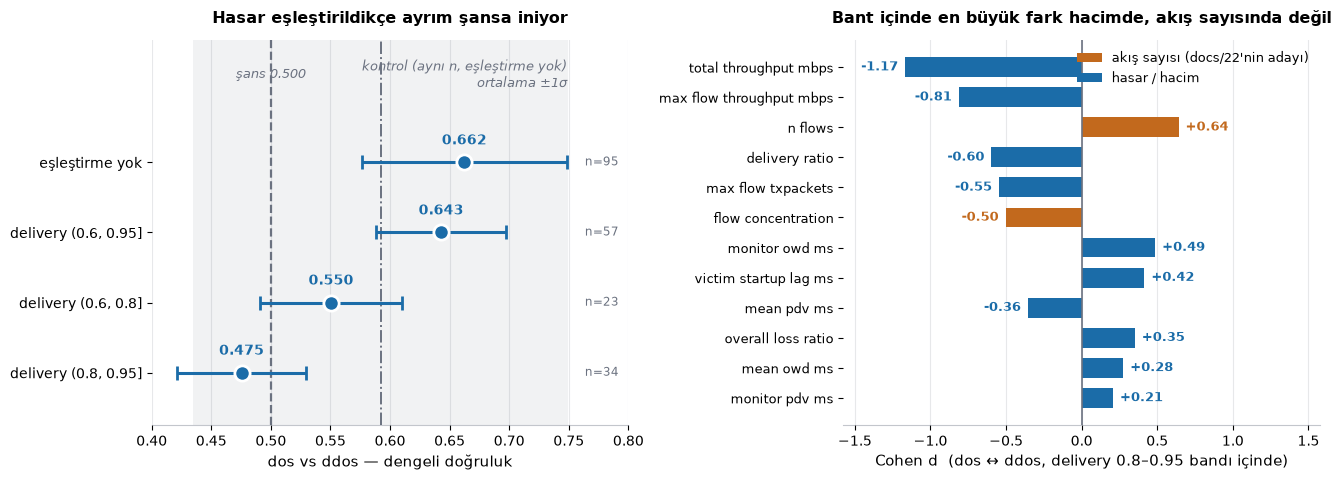

In [7]:
# --- Palet (dataviz validator: light 5/5 PASS, dark 5/5 PASS; protan ΔE 21.1) ---
C_DMG   = "#1b6ca8"   # mavi  -- hasar / hacim
C_STRUCT= "#c2691d"   # amber -- akis sayisi (docs/22'nin isaret ettigi aday)
C_INK   = "#6b7280"   # notr murekkep: sans cizgisi, kontrol bandi, eksenler

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))

# ============ Panel 1: eslestirme sikilastikca ayrim ============
# Nokta grafigi, bar DEGIL: anlamli taban 0 degil 0.500 (sans). Bar 0'dan baslayip
# yanlis bir oran izlenimi verirdi.
ax = axes[0]
order = ["eşleştirme yok", "delivery (0.6, 0.95]", "delivery (0.6, 0.8]", "delivery (0.8, 0.95]"]
ys = np.arange(len(order))[::-1]

ax.axvspan(ctrl.mean() - ctrl.std(), ctrl.mean() + ctrl.std(),
           color=C_INK, alpha=0.09, lw=0, zorder=0)
ax.axvline(ctrl.mean(), color=C_INK, lw=1.4, ls="-.", zorder=1)
ax.axvline(0.5, color=C_INK, lw=1.6, ls="--", zorder=1)

for y, tag in zip(ys, order):
    mu, sd, n = matched[tag]
    ax.errorbar(mu, y, xerr=sd, fmt="o", ms=11, color=C_DMG, lw=2.2,
                capsize=5, markeredgecolor="white", markeredgewidth=2, zorder=3)
    ax.annotate(f"{mu:.3f}", xy=(mu, y), xytext=(0, 13), textcoords="offset points",
                ha="center", color=C_DMG, fontsize=10, fontweight="bold")
    ax.annotate(f"n={n}", xy=(0.792, y), ha="right", va="center",
                color=C_INK, fontsize=8.5)

# Iki referans cizgisinin etiketi UST SERITTE, veri satirlarinin ustunde -> carpisma yok.
ax.annotate("şans 0.500", xy=(0.5, 4.25), ha="center", va="center",
            color=C_INK, fontsize=9, style="italic")
ax.annotate("kontrol (aynı n, eşleştirme yok)\nortalama ±1σ", xy=(0.7485, 4.25),
            ha="right", va="center", color=C_INK, fontsize=9, style="italic")

ax.set_yticks(ys); ax.set_yticklabels(order, fontsize=10)
ax.set_ylim(-0.75, 4.75)
ax.set_xlim(0.40, 0.80)
ax.set_xlabel("dos vs ddos — dengeli doğruluk", fontsize=10.5)
ax.set_title("Hasar eşleştirildikçe ayrım şansa iniyor", fontsize=11.5, fontweight="bold", pad=12)
ax.grid(axis="x", color=C_INK, alpha=0.16, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(C_INK); ax.spines["bottom"].set_alpha(0.4)

# ============ Panel 2: bant ici etki buyuklukleri ============
# Burada 0 ANLAMLI taban (etki yok) ve isaret yon tasiyor -> 0'dan iki yana bar dogru form.
ax = axes[1]
e = eff.iloc[::-1].reset_index(drop=True)
cols = [C_STRUCT if g == "akış sayısı" else C_DMG for g in e.grup]
ax.barh(np.arange(len(e)), e.d, color=cols, height=0.66, zorder=2)
ax.axvline(0, color=C_INK, lw=1.2, zorder=3)

for i, (v, g) in enumerate(zip(e.d, e.grup)):
    off = 5 if v >= 0 else -5
    ax.annotate(f"{v:+.2f}", xy=(v, i), xytext=(off, 0), textcoords="offset points",
                ha="left" if v >= 0 else "right", va="center",
                color=C_STRUCT if g == "akış sayısı" else C_DMG,
                fontsize=9, fontweight="bold")

ax.set_yticks(np.arange(len(e)))
ax.set_yticklabels([c.replace("_", " ") for c in e.feature], fontsize=9)
ax.set_xlabel("Cohen d  (dos ↔ ddos, delivery 0.8–0.95 bandı içinde)", fontsize=10.5)
ax.set_title("Bant içinde en büyük fark hacimde, akış sayısında değil",
             fontsize=11.5, fontweight="bold", pad=12)
lim = max(abs(e.d)) * 1.35
ax.set_xlim(-lim, lim)
ax.grid(axis="x", color=C_INK, alpha=0.16, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(C_INK); ax.spines["bottom"].set_alpha(0.4)

# Iki seri -> legend zorunlu (kimlik yalniz renkle tasinamaz)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=C_STRUCT, label="akış sayısı (docs/22'nin adayı)"),
                   Patch(facecolor=C_DMG, label="hasar / hacim")],
          loc="upper right", frameon=False, fontsize=9)

fig.tight_layout()
FIGS = Path("figs") if Path("figs").exists() else Path("my-work/day5-10072026-detector/figs")
fig.savefig(FIGS / "O-dos-ddos-hasar-ekseni.png", dpi=150, bbox_inches="tight")
print(f"kaydedildi: {FIGS / 'O-dos-ddos-hasar-ekseni.png'}")
plt.show()

## 6. Okuma

**docs/22 §3'ün sonucu geçersiz.** O bölüm "duran açıklama yanlış, hacim kontrol edildiğinde
dos/ddos ayrılıyor, ayrımı akış sayısı taşıyor" diyordu. Üçü de bu notebook'ta çürüyor:

1. Grid hacmi eşitledi ama **hasarı eşitlemedi** — saldırgan sayısıyla birlikte delivery,
   kayıp ve gecikme de kaydı (§1). "Yalnız saldırgan sayısı değişti" varsayımı yanlıştı.
2. **Hiçbir feature grubu gerekli değil**; ayrım tek bir eksende değil, hepsinin ortak
   izlediği tek boyutlu hasar ekseninde duruyor (ablasyon).
3. İşaret edilen aday — **akış sayısı — grupların en zayıfı**; hacim ondan yüksek. Bant
   içinde kalan etki büyüklükleri de aynı yönü gösteriyor (§4).

Dolayısıyla **duran açıklama ("tek güçlü flood ≈ birkaç zayıf flood, aynı hacim imzası")
aslında haklıydı** ve docs/22 onu yanlışlıkla çürütülmüş saymıştı.

**Ne demiyoruz.** "dos ve ddos temelde ayrılamaz" demiyoruz — §3'ün kontrolü buna izin
vermiyor. Diyebildiğimiz: *ayrılabilir olduğu iddiasının dayanağı geçersiz*, ve kalan
belirsizliği çözecek şey daha iyi bir grid değil, **daha çok ddos konfigi** (şu an 5 konfig
/ 25 koşu).

**Modele etkisi:** dos/ddos için yeni bir eğitim grid'i kurmak (v2) çürütülmüş bir öncüle
dayanırdı — yapılmadı. Bunun yerine sınırlılık model kartında olduğu gibi kaydediliyor.

**Projenin merkezî bulgusuna bağlanması.** Bu, aynı desenin üçüncü örneği:

| sınıf | etiketin iddiası | modelin gerçekte okuduğu |
|---|---|---|
| `greyhole` | "relay paket düşürüyor" | "yolda bir relay var" (docs/19) |
| `mitm` | "relay paketleri geciktiriyor" | "relay paket düşürmüyor" (docs/22 §1) |
| `ddos` | "saldırgan sayısı çok" | **"hasar çok"** (bu notebook) |

Üçünde de flow seviyesindeki koşu-özeti, saldırganın *ne yaptığını* değil ağın *ne kadar
bozulduğunu* ölçüyor. Bu, notebook 08'de yazılan "sorun algoritmada değil temsilde"
tespitinin doğrudan kanıtı.